<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana4/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine # Base nativa do Python

print("="*60)
print("CORREÇÃO DO LAB 2: INDÚSTRIA QUÍMICA (MULTICLASSE)")
print("="*60)

# 1. IMPORTAÇÃO DOS DADOS
dados_quimicos = load_wine()
X_dados = dados_quimicos.data   # 13 sensores químicos
Y_dados = dados_quimicos.target # Classes 0, 1 e 2
nomes_classes = dados_quimicos.target_names

print(f"Total de Bebidas: {len(X_dados)}")
print(f"Categorias: {len(nomes_classes)} ({nomes_classes[0]}, {nomes_classes[1]}, {nomes_classes[2]})")

CORREÇÃO DO LAB 2: INDÚSTRIA QUÍMICA (MULTICLASSE)
Total de Bebidas: 178
Categorias: 3 (class_0, class_1, class_2)


In [48]:
print(X_dados)

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]


In [49]:
np.unique(Y_dados, return_counts=True)

(array([0, 1, 2]), array([59, 71, 48]))

In [50]:
X_temp, X_test, Y_temp, Y_test = train_test_split(X_dados, Y_dados, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42)

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [52]:
modelo_quimico = Sequential(name="Classificador_Multiclasse_V1")
modelo_quimico.add(Input(shape=(13,), name="Input_13_Sensores"))
modelo_quimico.add(Dense(32, activation='relu', name="Oculta_1"))
modelo_quimico.add(Dense(16, activation='relu', name="Oculta_2"))
modelo_quimico.add(Dense(3, activation='softmax', name="Saida_3_Classes"))

In [53]:
modelo_quimico.summary()

Model: "Classificador_Multiclasse_V1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Oculta_1 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_3_Classes (Dense)         │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027 (4.01 KB)

 Trainable params: 1,027 (4.01 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
modelo_quimico.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [55]:
freio = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)


In [56]:
historico = modelo_quimico.fit(
    X_train_scaled, Y_train,
    validation_data=(X_val_scaled, Y_val),
    epochs=100, batch_size=16,
    callbacks=[freio], verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.3363 - loss: 1.1449 - val_accuracy: 0.3793 - val_loss: 1.1469
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4602 - loss: 1.0535 - val_accuracy: 0.5172 - val_loss: 1.0642
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5664 - loss: 0.9805 - val_accuracy: 0.6207 - val_loss: 0.9866
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6460 - loss: 0.9140 - val_accuracy: 0.6897 - val_loss: 0.9154
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7345 - loss: 0.8497 - val_accuracy: 0.7241 - val_loss: 0.8470
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8142 - loss: 0.7881 - val_accuracy: 0.7241 - val_loss: 0.7839
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8850 - loss: 0.7290 - val_accuracy: 0.8276 - val_loss: 0.7244
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9027 - loss: 0.6753 - val_accuracy: 0.8621 - val_loss:

In [30]:
previsoes_prob = modelo_quimico.predict(X_test_scaled)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [31]:
print("\nExemplo da Primeira Bebida Inédita:")
print(f"Probabilidades (Softmax): {previsoes_prob[0]*100}")
chute_final_exemplo = np.argmax(previsoes_prob[0])
print(f"O np.argmax escolheu a Classe {chute_final_exemplo} como vencedora!")



Exemplo da Primeira Bebida Inédita:
Probabilidades (Softmax): [9.9962921e+01 1.5533433e-02 2.1548275e-02]
O np.argmax escolheu a Classe 0 como vencedora!


In [32]:
previsoes_finais = np.argmax(previsoes_prob, axis=1)


In [33]:
print(classification_report(Y_test, previsoes_finais, target_names=nomes_classes))


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



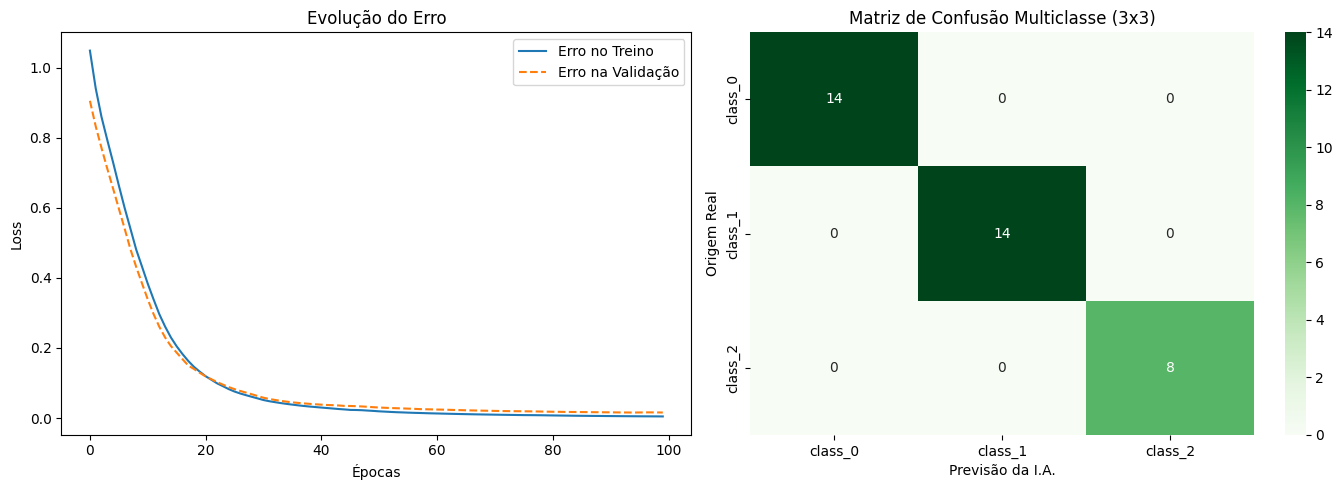

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(historico.history['loss'], label='Erro no Treino')
ax1.plot(historico.history['val_loss'], label='Erro na Validação', linestyle='--')
ax1.set_title("Evolução do Erro")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss")
ax1.legend()

matriz = confusion_matrix(Y_test, previsoes_finais)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=nomes_classes, yticklabels=nomes_classes)
ax2.set_title("Matriz de Confusão Multiclasse (3x3)")
ax2.set_xlabel("Previsão da I.A.")
ax2.set_ylabel("Origem Real")
plt.tight_layout()
plt.show()